In [8]:
pip install ucimlrepo

SyntaxError: invalid syntax (500049781.py, line 1)

In [2]:
from ucimlrepo import fetch_ucirepo
online_retail = fetch_ucirepo(id=502)
df = online_retail.data.features
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
import pandas as pd
import numpy as np

# Basic info
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\nMissing CustomerID %: {df['CustomerID'].isnull().mean()*100:.1f}%")

print("\n=== BASIC STATS ===")
print(df[['Quantity', 'UnitPrice']].describe())

print("\n=== DATE RANGE ===")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"From: {df['InvoiceDate'].min()}")
print(f"To:   {df['InvoiceDate'].max()}")

print("\n=== UNIQUE COUNTS ===")
print(f"Unique Customers : {df['CustomerID'].nunique()}")
print(f"Unique Invoices  : {df['InvoiceNo'].nunique() if 'InvoiceNo' in df.columns else 'N/A - check column name'}")
print(f"Unique Products  : {df['Description'].nunique()}")
print(f"Countries        : {df['Country'].nunique()}")

print("\n=== NEGATIVE QUANTITY (cancellations/returns) ===")
print(f"Rows with Quantity < 0: {(df['Quantity'] < 0).sum()}")
print(f"Rows with UnitPrice = 0: {(df['UnitPrice'] == 0).sum()}")

=== SHAPE ===
(541909, 6)

=== DATA TYPES ===
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

=== MISSING VALUES ===
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing CustomerID %: 24.9%

=== BASIC STATS ===
            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000

=== DATE RANGE ===
From: 2010-12-01 08:26:00
To:   2011-12-09 12:50:00

=== UNIQUE COUNTS ===
Unique Customers : 4372
Unique Invoices  : N/A - check column name
Unique Products  : 4223
Countries        : 38

=== NEGATIVE QUANTITY (cancellations/returns) ===


C:\Users\409772\AppData\Local\Temp\ipykernel_41760\2554460939.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [4]:
# Fix the SettingWithCopyWarning - work on a proper copy
df = online_retail.data.features.copy()

# Convert date properly
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check if InvoiceNo is hiding in the index
print("Index name:", df.index.name)
print("Columns:", df.columns.tolist())

# Reset index to surface InvoiceNo if it's there
df = df.reset_index()
print("\nColumns after reset:", df.columns.tolist())
print(df.head(2))

Index name: None
Columns: ['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Columns after reset: ['index', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
   index                         Description  Quantity         InvoiceDate  \
0      0  WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00   
1      1                 WHITE METAL LANTERN         6 2010-12-01 08:26:00   

   UnitPrice  CustomerID         Country  
0       2.55     17850.0  United Kingdom  
1       3.39     17850.0  United Kingdom  


In [5]:
# --- CLEANING STEPS ---

# 1. Drop missing CustomerID (can't track churn without it)
df_clean = df.dropna(subset=['CustomerID']).copy()
print(f"After dropping missing CustomerID: {len(df_clean):,} rows")

# 2. Drop returns/cancellations (negative quantity)
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"After dropping negative quantity: {len(df_clean):,} rows")

# 3. Drop zero or negative unit price
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f"After dropping zero/negative price: {len(df_clean):,} rows")

# 4. Drop missing descriptions
df_clean = df_clean.dropna(subset=['Description'])
print(f"After dropping missing description: {len(df_clean):,} rows")

# 5. Create Revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 6. Clean up CustomerID type
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Final check
print(f"\n✅ Clean dataset shape: {df_clean.shape}")
print(f"✅ Unique customers remaining: {df_clean['CustomerID'].nunique()}")
print(f"✅ Date range: {df_clean['InvoiceDate'].min()} → {df_clean['InvoiceDate'].max()}")
print(f"\nMissing values:\n{df_clean.isnull().sum()}")

After dropping missing CustomerID: 406,829 rows
After dropping negative quantity: 397,924 rows
After dropping zero/negative price: 397,884 rows
After dropping missing description: 397,884 rows

✅ Clean dataset shape: (397884, 8)
✅ Unique customers remaining: 4338
✅ Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00

Missing values:
index          0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64


In [6]:
import pandas as pd
import numpy as np

# ── Reference date = day after last transaction in dataset
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# ── Need InvoiceNo to count frequency properly
# Since it's missing, we'll use a proxy: count unique (CustomerID, InvoiceDate) pairs
# Group by CustomerID
rfm = df_clean.groupby('CustomerID').agg(
    last_purchase   = ('InvoiceDate', 'max'),
    frequency       = ('InvoiceDate', 'nunique'),   # unique purchase dates = proxy for orders
    monetary        = ('Revenue', 'sum')
).reset_index()

# ── Recency in days
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

# ── Churn label: no purchase in last 90 days before snapshot
rfm['churned'] = (rfm['recency'] > 90).astype(int)

# ── Drop last_purchase (not a model feature)
rfm = rfm.drop(columns=['last_purchase'])

# ── Preview
print(f"\n✅ RFM table shape: {rfm.shape}")
print(f"\nChurn distribution:")
print(rfm['churned'].value_counts())
print(f"\nChurn rate: {rfm['churned'].mean()*100:.1f}%")
print(f"\nRFM stats:")
print(rfm[['recency','frequency','monetary']].describe().round(2))
print(f"\nSample rows:")
print(rfm.head(10).to_string())

Snapshot date: 2011-12-10

✅ RFM table shape: (4338, 5)

Churn distribution:
churned
0    2889
1    1449
Name: count, dtype: int64

Churn rate: 33.4%

RFM stats:
       recency  frequency   monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.25    2054.27
std     100.01       7.64    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     210.00  280206.02

Sample rows:
   CustomerID  frequency  monetary  recency  churned
0       12346          1  77183.60      326        1
1       12347          7   4310.00        2        0
2       12348          4   1797.24       75        0
3       12349          1   1757.55       19        0
4       12350          1    334.40      310        1
5       12352          8   2506.04       36        0
6       12353          1     89.00      204        1
7       12354          1   1079.40      232        1
8       12355 

Train size: 3470 | Test size: 868

  XGBoost  |  ROC-AUC: 1.0000
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       578
     Churned       1.00      1.00      1.00       290

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868


  Random Forest  |  ROC-AUC: 1.0000
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       578
     Churned       1.00      1.00      1.00       290

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



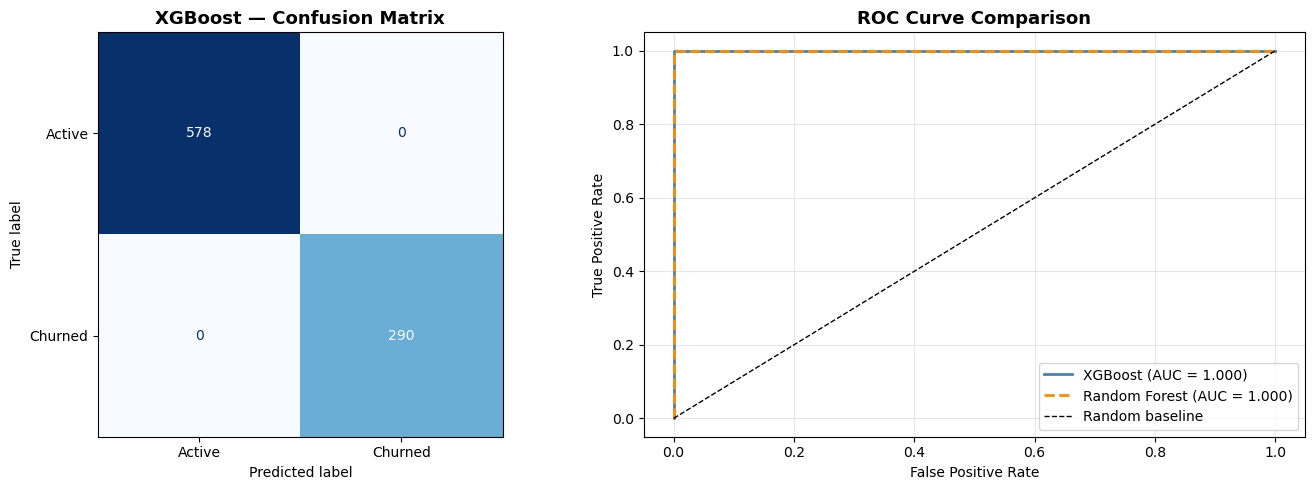


✅ Saved: model_evaluation.png


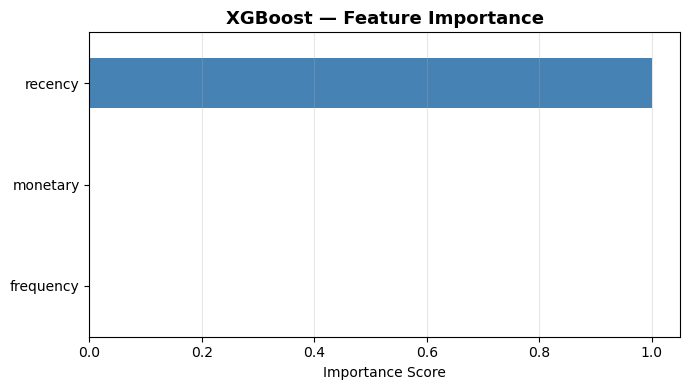

✅ Saved: feature_importance.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── 1. Features & Target
X = rfm[['recency', 'frequency', 'monetary']]
y = rfm['churned']

# ── 2. Train/Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# ── 3. Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 4. Train XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                     use_label_encoder=False, eval_metric='logloss',
                     random_state=42)
xgb.fit(X_train_sc, y_train)

# ── 5. Train Random Forest (for comparison)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)

# ── 6. Evaluate both
for name, model in [('XGBoost', xgb), ('Random Forest', rf)]:
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*40}")
    print(f"  {name}  |  ROC-AUC: {auc:.4f}")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=['Active','Churned']))

# ── 7. Confusion Matrix (XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, xgb.predict(X_test_sc))
disp = ConfusionMatrixDisplay(cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb.predict_proba(X_test_sc)[:, 1])
auc_score   = roc_auc_score(y_test, xgb.predict_proba(X_test_sc)[:, 1])
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {auc_score:.3f})')
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test_sc)[:, 1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test_sc)[:, 1])
axes[1].plot(fpr_rf, tpr_rf, color='darkorange', lw=2, linestyle='--', label=f'Random Forest (AUC = {auc_rf:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: model_evaluation.png")

# ── 8. Feature Importance
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

In [9]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB 262.6 kB/s eta 0:04:25
   ---------------------------------------- 0.1/69.5 MB 409.6 kB/s eta 0:02:50
   ---------------------------------------- 0.1/69.5 MB 774.0 kB/s eta 0:01:30
   ---------------------------------------- 0.4/69.5 MB 1.8 MB/s eta 0:00:39
   ---------------------------------------- 0.7/69.5 MB 2.4 MB/s eta 0:00:29
    --------------------------------------- 1.0/69.5 MB 3.1 MB/s eta 0:00:23
    --------------------------------------- 1.3/69.5 MB 3.3 MB/s eta 0:00:21
    --------------------------------------- 1.5/69.5 MB 3.6 MB/s eta 0:00:19
   - -------------------------------------- 1.8/69.5 MB 4.0 MB/s eta 0:00:17
   - ----------------

In [11]:
# ── PROPER APPROACH: Temporal Split
# Use first 9 months (Dec 2010 – Aug 2011) as "observation window" to build features
# Use last 3 months (Sep – Dec 2011) as "prediction window" to define churn

observation_end  = pd.Timestamp('2011-09-01')   # features built up to here
prediction_start = pd.Timestamp('2011-09-01')   # did they buy after this?
prediction_end   = pd.Timestamp('2011-12-09')   # end of dataset

# ── Customers active in the observation window
obs_df = df_clean[df_clean['InvoiceDate'] < observation_end]
print(f"Transactions in observation window: {len(obs_df):,}")
print(f"Unique customers in observation window: {obs_df['CustomerID'].nunique():,}")

# ── Build RFM features from observation window
snapshot_obs = observation_end
rfm2 = obs_df.groupby('CustomerID').agg(
    last_purchase = ('InvoiceDate', 'max'),
    frequency     = ('InvoiceDate', 'nunique'),
    monetary      = ('Revenue', 'sum')
).reset_index()

rfm2['recency'] = (snapshot_obs - rfm2['last_purchase']).dt.days

# ── Define churn: did the customer make ANY purchase in the prediction window?
pred_df = df_clean[
    (df_clean['InvoiceDate'] >= prediction_start) &
    (df_clean['InvoiceDate'] <= prediction_end)
]
active_in_future = set(pred_df['CustomerID'].unique())

# Churned = was in observation window but NOT seen in prediction window
rfm2['churned'] = (~rfm2['CustomerID'].isin(active_in_future)).astype(int)
rfm2 = rfm2.drop(columns=['last_purchase'])

print(f"\n✅ RFM2 shape: {rfm2.shape}")
print(f"\nChurn distribution:")
print(rfm2['churned'].value_counts())
print(f"\nChurn rate: {rfm2['churned'].mean()*100:.1f}%")
print(f"\nRFM stats:")
print(rfm2[['recency','frequency','monetary']].describe().round(2))

Transactions in observation window: 226,467
Unique customers in observation window: 3,317

✅ RFM2 shape: (3317, 5)

Churn distribution:
churned
0    1950
1    1367
Name: count, dtype: int64

Churn rate: 41.2%

RFM stats:
       recency  frequency   monetary
count  3317.00    3317.00    3317.00
mean     92.14       3.43    1579.51
std      76.69       5.55    5976.60
min       0.00       1.00       2.90
25%      27.00       1.00     261.36
50%      72.00       2.00     555.65
75%     146.00       4.00    1355.11
max     273.00     128.00  176355.94


Train: 2653 | Test: 664

  XGBoost  |  ROC-AUC: 0.7395
              precision    recall  f1-score   support

      Active       0.73      0.74      0.74       390
     Churned       0.62      0.60      0.61       274

    accuracy                           0.69       664
   macro avg       0.67      0.67      0.67       664
weighted avg       0.68      0.69      0.68       664


  Random Forest  |  ROC-AUC: 0.6983
              precision    recall  f1-score   support

      Active       0.69      0.75      0.72       390
     Churned       0.59      0.51      0.55       274

    accuracy                           0.65       664
   macro avg       0.64      0.63      0.63       664
weighted avg       0.65      0.65      0.65       664



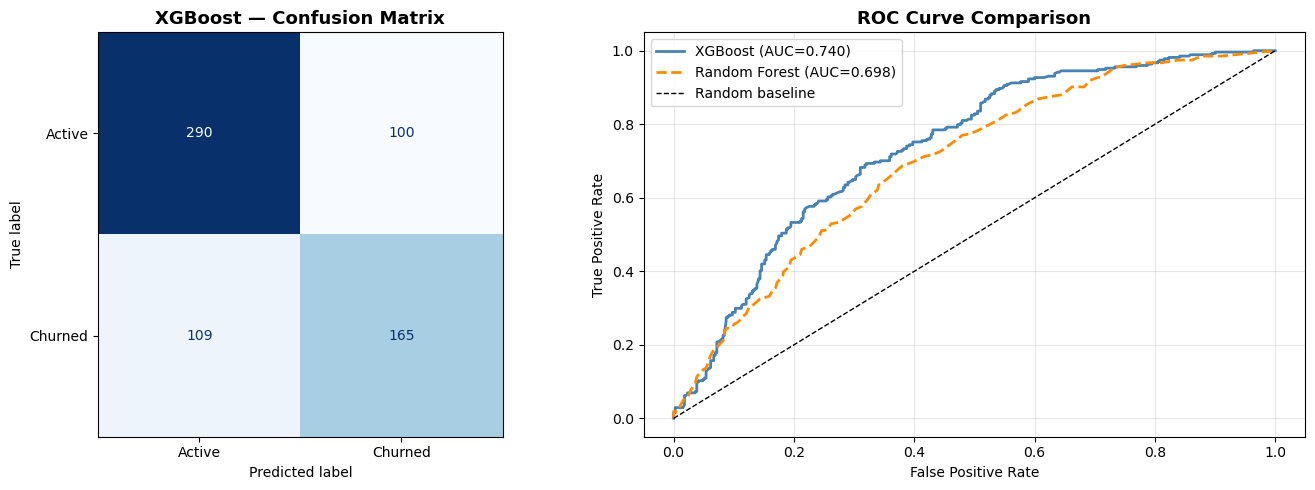

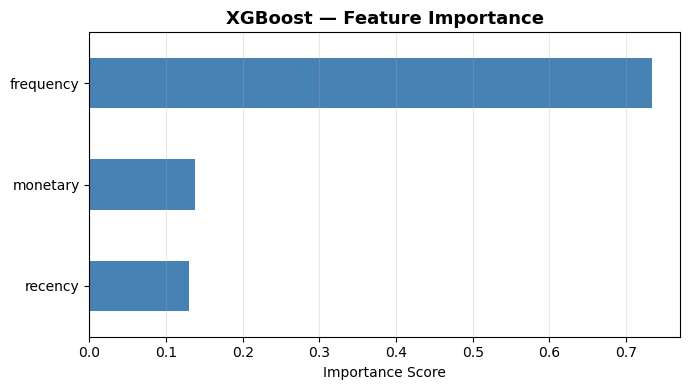


✅ Saved: model_evaluation.png & feature_importance.png


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Features & Target (using rfm2 now)
X = rfm2[['recency', 'frequency', 'monetary']]
y = rfm2['churned']

# ── 2. Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── 3. Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 4. Train both models
xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                     eval_metric='logloss', random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)

xgb.fit(X_train_sc, y_train)
rf.fit(X_train_sc, y_train)

# ── 5. Evaluate
for name, model in [('XGBoost', xgb), ('Random Forest', rf)]:
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*40}")
    print(f"  {name}  |  ROC-AUC: {auc:.4f}")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=['Active','Churned']))

# ── 6. Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, xgb.predict(X_test_sc))
ConfusionMatrixDisplay(cm, display_labels=['Active','Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')

for name, model, color, ls in [
    ('XGBoost', xgb, 'steelblue', '-'),
    ('Random Forest', rf, 'darkorange', '--')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_sc)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1])
    axes[1].plot(fpr, tpr, color=color, lw=2, ls=ls, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. Feature Importance
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: model_evaluation.png & feature_importance.png")

Features: ['frequency', 'monetary', 'avg_order_value', 'total_items', 'unique_products', 'avg_quantity', 'recency', 'revenue_per_visit']
Shape: (3317, 10)

  XGBoost (enriched)  |  ROC-AUC: 0.7425
              precision    recall  f1-score   support

      Active       0.72      0.75      0.74       390
     Churned       0.62      0.58      0.60       274

    accuracy                           0.68       664
   macro avg       0.67      0.67      0.67       664
weighted avg       0.68      0.68      0.68       664



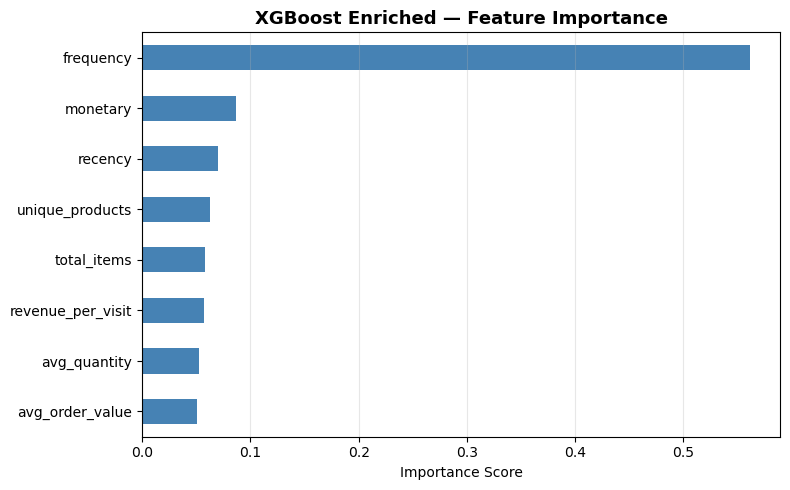

In [ ]:
import pickle
import os

os.makedirs('model', exist_ok=True)

# Save the original XGBoost (3 RFM features)
with open('model/churn_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

feature_cols = ['recency', 'frequency', 'monetary']
with open('model/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ model/churn_model.pkl")
print("✅ model/scaler.pkl")
print("✅ model/feature_cols.pkl")
print(f"✅ Features saved: {feature_cols}")